# Sections 3-5: English-First Clinical Modeling and Frozen Transfer to Ukrainian

This notebook implements the paper-facing analysis for:

1. **Section 3**: English-first model development on E-DAIC.
2. **Section 4**: frozen transfer of the English-selected model to the translated Ukrainian representation.
3. **Section 5**: comparison of clinical signal retention across nested consistency families.

## Scientific framing

The goal here is **not** to claim native Ukrainian clinical screening performance. The goal is to test whether the
Ukrainian-adapted pipeline preserves clinically relevant signal when the **same clinical interviews** are represented
in Ukrainian and processed by the Ukrainian feature extraction stack.

We therefore:

- develop models on **English** only,
- freeze preprocessing, coefficients, and threshold,
- apply the same decision rule to the translated **Ukrainian** version of the same interviews,
- and compare retention across predefined consistency families.


In [1]:
from __future__ import annotations

import hashlib
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, f1_score, roc_auc_score
from sklearn.model_selection import StratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MaxAbsScaler

from IPython.display import display

plt.style.use("seaborn-v0_8-whitegrid")
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 200)

PACKAGE_ROOT = Path("/Users/poluidol/Documents/work/airest/airest_perp_research/data_analysis/tmp/paper_sections_3_4_5_signal_retention_clean")
OUT_DIR = PACKAGE_ROOT / "results" / "signal_retention_notebook"
FIG_DIR = OUT_DIR / "figures"
BASELINE_SWEEP_DIR = PACKAGE_ROOT / "results" / "baseline_sweep"
OUT_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

EN_PATH = PACKAGE_ROOT / "data" / "inputs" / "summary_en_3_4_2026_expanded_b0_union_features.csv"
UA_PATH = PACKAGE_ROOT / "data" / "inputs" / "summary_ukr_3_4_2026_expanded_b0_union_features.csv"
CONSISTENCY_PATH = PACKAGE_ROOT / "data" / "inputs" / "consistency_en_ua_all_plus_sentiment_hist.csv"

TARGETS = ["Depression_label", "PTSD_label"]
LABEL_DROP = {
    "Participant",
    "split",
    "Depression_label",
    "PTSD_label",
    "Depression_severity",
    "PTSD_severity",
}
FAMILY_ORDER = ["B0_rho05_vaderfull", "B07_from_B0", "B09_from_B0"]
FAMILY_LABELS = {
    "B0_rho05_vaderfull": "B0: rho>0.5 + full VADER hist",
    "B07_from_B0": "B07: B0 filtered to rho>0.7",
    "B09_from_B0": "B09: B0 filtered to rho>0.9",
}
SEED = 42
SENTIMENT_COLUMNS = [f"vader_hist_bin_{idx:02d}" for idx in range(1, 24)] + [
    "vader_hist_entropy",
    "vader_neg_tail_mass",
    "vader_pos_tail_mass",
    "vader_neutral_mass",
    "participant_utterance_count",
]


class SimpleRobustTransformer(BaseEstimator, TransformerMixin):
    def __init__(
        self,
        clip_low=0.005,
        clip_high=0.995,
        add_missing_indicators=False,
        log_perplexity=True,
    ):
        self.clip_low = clip_low
        self.clip_high = clip_high
        self.add_missing_indicators = add_missing_indicators
        self.log_perplexity = log_perplexity

    def fit(self, X, y=None):
        X = pd.DataFrame(X).copy()
        self.columns_ = list(X.columns)
        self.perplexity_cols_ = [c for c in self.columns_ if "semantic_perplexity" in c]
        self.quantiles_ = {}
        self.medians_ = {}
        self.missing_cols_ = []
        X_t = self._apply_log(X)
        for c in self.columns_:
            s = pd.to_numeric(X_t[c], errors="coerce")
            lo = s.quantile(self.clip_low)
            hi = s.quantile(self.clip_high)
            if not np.isfinite(lo):
                lo = np.nan
            if not np.isfinite(hi):
                hi = np.nan
            self.quantiles_[c] = (lo, hi)
            self.medians_[c] = s.median(skipna=True)
            if self.add_missing_indicators and s.isna().any():
                self.missing_cols_.append(c)
        return self

    def _apply_log(self, X):
        X = X.copy()
        if self.log_perplexity:
            for c in self.perplexity_cols_:
                s = pd.to_numeric(X[c], errors="coerce").clip(lower=0)
                X[c] = np.log1p(s)
        return X

    def transform(self, X):
        X = pd.DataFrame(X).copy().reindex(columns=self.columns_)
        X_t = self._apply_log(X)
        out = []
        for c in self.columns_:
            s = pd.to_numeric(X_t[c], errors="coerce")
            lo, hi = self.quantiles_[c]
            if np.isfinite(lo):
                s = s.clip(lower=lo)
            if np.isfinite(hi):
                s = s.clip(upper=hi)
            if self.add_missing_indicators and c in self.missing_cols_:
                out.append(s.isna().astype(float).to_numpy().reshape(-1, 1))
            med = self.medians_[c]
            if not np.isfinite(med):
                med = 0.0
            out.append(s.fillna(med).to_numpy().reshape(-1, 1))
        return np.concatenate(out, axis=1).astype(np.float64)


def tune_threshold(y_true: pd.Series | np.ndarray, proba: np.ndarray) -> tuple[float, float, float]:
    candidates = np.unique(np.quantile(proba, np.linspace(0.0, 1.0, 101)))
    best_thr = 0.5
    best_f1m = -1.0
    best_f1b = -1.0
    y_true_arr = np.asarray(y_true, dtype=int)
    for thr in candidates:
        y_pred = (proba >= thr).astype(int)
        f1m = f1_score(y_true_arr, y_pred, average="macro", zero_division=0)
        f1b = f1_score(y_true_arr, y_pred, average="binary", zero_division=0)
        if (f1m > best_f1m) or (np.isclose(f1m, best_f1m) and f1b > best_f1b):
            best_f1m = float(f1m)
            best_f1b = float(f1b)
            best_thr = float(thr)
    return best_thr, best_f1m, best_f1b


def safe_roc_auc(y_true: pd.Series | np.ndarray, proba: np.ndarray) -> float:
    y = np.asarray(y_true, dtype=int)
    if len(np.unique(y)) < 2:
        return float("nan")
    return float(roc_auc_score(y, proba))


def metrics_at_threshold(y_true: pd.Series | np.ndarray, proba: np.ndarray, threshold: float) -> dict[str, float]:
    y = np.asarray(y_true, dtype=int)
    pred = (proba >= threshold).astype(int)
    return {
        "pr_auc": float(average_precision_score(y, proba)),
        "f1_macro": float(f1_score(y, pred, average="macro", zero_division=0)),
        "f1_binary": float(f1_score(y, pred, average="binary", zero_division=0)),
        "accuracy": float(accuracy_score(y, pred)),
        "roc_auc": float(safe_roc_auc(y, proba)),
    }


def train_test_split_for_target(df: pd.DataFrame, target: str, feature_cols: list[str]):
    split = df["split"].astype(str).str.lower().str.strip()
    train_mask = split.isin(["train", "dev"])
    test_mask = split.eq("test")
    X_train = df.loc[train_mask, feature_cols].reset_index(drop=True)
    y_train = df.loc[train_mask, target].astype(int).reset_index(drop=True)
    X_test = df.loc[test_mask, feature_cols].reset_index(drop=True)
    y_test = df.loc[test_mask, target].astype(int).reset_index(drop=True)
    return X_train, y_train, X_test, y_test


def class_weight_options(target: str):
    if target == "Depression_label":
        return [
            ("bal", "balanced"),
            ("cwpos1.8", {0: 1.0, 1: 1.8}),
            ("cwpos2.0", {0: 1.0, 1: 2.0}),
            ("cwpos2.2", {0: 1.0, 1: 2.2}),
        ]
    return [
        ("bal", "balanced"),
        ("cwpos2.4", {0: 1.0, 1: 2.4}),
        ("cwpos2.8", {0: 1.0, 1: 2.8}),
        ("cwpos3.2", {0: 1.0, 1: 3.2}),
    ]


def make_config_key(payload: dict[str, object]) -> str:
    raw = json.dumps(payload, sort_keys=True, ensure_ascii=True)
    return hashlib.sha1(raw.encode("utf-8")).hexdigest()


def build_pipeline_from_payload(payload: dict[str, object]) -> Pipeline:
    prep = SimpleRobustTransformer(
        clip_low=payload["preproc"]["clip_low"],
        clip_high=payload["preproc"]["clip_high"],
        add_missing_indicators=payload["preproc"]["add_missing_indicators"],
        log_perplexity=payload["preproc"]["log_perplexity"],
    )
    model_params = dict(payload["model"]["params"])
    class_weight = model_params.get("class_weight")
    if isinstance(class_weight, dict):
        model_params["class_weight"] = {int(k): float(v) for k, v in class_weight.items()}
    model_params.setdefault("random_state", SEED)
    model = LogisticRegression(**model_params)
    return Pipeline([
        ("prep", prep),
        ("scale", MaxAbsScaler()),
        ("model", model),
    ])


def predict_scores(pipe: Pipeline, X: pd.DataFrame) -> np.ndarray:
    return pipe.predict_proba(X)[:, 1]


def repeated_cv_summary(payload: dict[str, object], X_train: pd.DataFrame, y_train: pd.Series, n_splits: int, n_repeats: int):
    n = len(y_train)
    acc = np.zeros(n, dtype=float)
    repeat_rows = []
    for repeat_idx in range(n_repeats):
        cv = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=SEED + 97 * (repeat_idx + 1))
        oof = np.zeros(n, dtype=float)
        for tr, va in cv.split(X_train, y_train):
            pipe = build_pipeline_from_payload(payload)
            pipe.fit(X_train.iloc[tr], y_train.iloc[tr])
            oof[va] = predict_scores(pipe, X_train.iloc[va])
        thr, f1m, f1b = tune_threshold(y_train, oof)
        pr = float(average_precision_score(y_train, oof))
        roc = safe_roc_auc(y_train, oof)
        repeat_rows.append({
            "oof_pr_auc": pr,
            "oof_f1_macro": float(f1m),
            "oof_f1_binary": float(f1b),
            "oof_roc_auc": float(roc),
            "threshold": float(thr),
        })
        acc += oof
    avg_oof = acc / float(n_repeats)
    avg_thr, avg_f1m, avg_f1b = tune_threshold(y_train, avg_oof)
    rep_pr = np.asarray([row["oof_pr_auc"] for row in repeat_rows], dtype=float)
    rep_f1 = np.asarray([row["oof_f1_macro"] for row in repeat_rows], dtype=float)
    return {
        "mean_oof_pr": float(rep_pr.mean()),
        "std_oof_pr": float(rep_pr.std(ddof=0)),
        "mean_oof_f1": float(rep_f1.mean()),
        "std_oof_f1": float(rep_f1.std(ddof=0)),
        "mean_oof_f1_binary": float(np.mean([row["oof_f1_binary"] for row in repeat_rows])),
        "mean_oof_roc": float(np.nanmean([row["oof_roc_auc"] for row in repeat_rows])),
        "threshold_final": float(avg_thr),
        "threshold_rule": f"macro_f1 on repeated_oof_avg ({n_splits}x{n_repeats})",
    }


def fit_and_eval_official(payload: dict[str, object], X_train: pd.DataFrame, y_train: pd.Series, X_test: pd.DataFrame, y_test: pd.Series, threshold: float):
    pipe = build_pipeline_from_payload(payload)
    pipe.fit(X_train, y_train)
    p_test = predict_scores(pipe, X_test)
    metrics = metrics_at_threshold(y_test, p_test, threshold)
    return metrics, p_test


## Data loading and train+dev consistency-tier family definitions
`B0_rho05_vaderfull` is kept fixed as the baseline family from the compact input files. Sections 3-6 recompute EN-UA consistency on paired `train+dev` rows only and use that train+dev rho map only for the derived tiers `B07_from_B0` and `B09_from_B0`. Section 0 remains the previously completed fixed-family baseline sweep used only as benchmark context.

In [2]:
en_df = pd.read_csv(EN_PATH)
ua_df = pd.read_csv(UA_PATH)
consistency_reference_df = pd.read_csv(CONSISTENCY_PATH)

# Basic dataset alignment checks for the paired EN-UA design.
assert set(en_df["Participant"]) == set(ua_df["Participant"])
assert set(en_df["split"].astype(str).str.lower()) == set(ua_df["split"].astype(str).str.lower())

en_test_ids = sorted(en_df.loc[en_df["split"].astype(str).str.lower().eq("test"), "Participant"].tolist())
ua_test_ids = sorted(ua_df.loc[ua_df["split"].astype(str).str.lower().eq("test"), "Participant"].tolist())
assert en_test_ids == ua_test_ids

feature_order = [c for c in en_df.columns if c not in LABEL_DROP]
vader_full = [c for c in SENTIMENT_COLUMNS if c in feature_order]
b0_features = list(feature_order)

split_en = en_df["split"].astype(str).str.lower().str.strip()
split_ua = ua_df["split"].astype(str).str.lower().str.strip()
train_dev_en = (
    en_df.loc[split_en.isin(["train", "dev"]), ["Participant", "split"] + feature_order]
    .sort_values("Participant")
    .reset_index(drop=True)
)
train_dev_ua = (
    ua_df.loc[split_ua.isin(["train", "dev"]), ["Participant", "split"] + feature_order]
    .sort_values("Participant")
    .reset_index(drop=True)
)

assert train_dev_en["Participant"].tolist() == train_dev_ua["Participant"].tolist()
assert (
    train_dev_en["split"].astype(str).str.lower().str.strip().tolist()
    == train_dev_ua["split"].astype(str).str.lower().str.strip().tolist()
)

consistency_rows = []
for feat in feature_order:
    s_en = pd.to_numeric(train_dev_en[feat], errors="coerce")
    s_ua = pd.to_numeric(train_dev_ua[feat], errors="coerce")
    valid = s_en.notna() & s_ua.notna()
    if int(valid.sum()) < 3 or s_en.loc[valid].nunique() <= 1 or s_ua.loc[valid].nunique() <= 1:
        rho = np.nan
    else:
        rho = float(s_en.loc[valid].corr(s_ua.loc[valid], method="spearman"))
    consistency_rows.append(
        {
            "feature": feat,
            "spearman_rho": rho,
            "n_train_dev_pairs": int(valid.sum()),
        }
    )

consistency_df = pd.DataFrame(consistency_rows)
reference_rho_map = dict(zip(consistency_reference_df["feature"], consistency_reference_df["spearman_rho"]))
rho_map = dict(zip(consistency_df["feature"], consistency_df["spearman_rho"]))

consistency_df["reference_spearman_rho"] = consistency_df["feature"].map(reference_rho_map)
consistency_df["delta_vs_reference"] = consistency_df["spearman_rho"] - consistency_df["reference_spearman_rho"]
consistency_df.to_csv(OUT_DIR / "train_dev_consistency.csv", index=False)

family_features = {
    "B0_rho05_vaderfull": b0_features,
}
family_features["B07_from_B0"] = [
    c for c in family_features["B0_rho05_vaderfull"] if rho_map.get(c, float("-inf")) > 0.7
]
family_features["B09_from_B0"] = [
    c for c in family_features["B0_rho05_vaderfull"] if rho_map.get(c, float("-inf")) > 0.9
]

family_count_rows = []
for family_name in FAMILY_ORDER:
    feats = family_features[family_name]
    vader_count = sum((f.startswith("vader_") or f == "participant_utterance_count") for f in feats)
    family_count_rows.append(
        {
            "family": family_name,
            "label": FAMILY_LABELS[family_name],
            "n_features": len(feats),
            "n_vader": vader_count,
            "n_nonvader": len(feats) - vader_count,
        }
    )

family_counts_df = pd.DataFrame(family_count_rows)
family_counts_df.to_csv(OUT_DIR / "family_feature_counts.csv", index=False)

family_long_df = pd.DataFrame(
    [
        {
            "family": family_name,
            "feature": feat,
            "spearman_rho": rho_map.get(feat, np.nan),
            "reference_spearman_rho": reference_rho_map.get(feat, np.nan),
            "is_fixed_b0": family_name == "B0_rho05_vaderfull",
        }
        for family_name, feats in family_features.items()
        for feat in feats
    ]
)
family_long_df.to_csv(OUT_DIR / "family_feature_membership.csv", index=False)

display(family_counts_df)

,family,label,n_features,n_vader,n_nonvader
0,B0_rho05_vaderfull,B0: rho>0.5 + full VADER hist,82,28,54
1,B07_from_B0,B07: B0 filtered to rho>0.7,53,5,48
2,B09_from_B0,B09: B0 filtered to rho>0.9,20,1,19


## Section 0. English baseline challenger benchmark from the completed family sweep

Before the frozen EN-to-UA transfer analysis, we anchor the notebook with the already completed
`stable_rho_gt_05 + full_vader_hist` family sweep. This gives the best **English-side row for each model family**
on the baseline feature set, plus the overall winner by target.

This section is read from disk, not recomputed here, so the notebook keeps one consistent reference point
for why the later transfer analysis fixes the model family to `l2 liblinear`.


In [3]:
baseline_by_family_path = BASELINE_SWEEP_DIR / "best_by_family_target.csv"
baseline_by_target_path = BASELINE_SWEEP_DIR / "best_by_target.csv"

baseline_by_family_df = pd.read_csv(baseline_by_family_path)
baseline_by_target_df = pd.read_csv(baseline_by_target_path)

baseline_feature_group = "stable_rho_gt_05__full_vader_hist"

baseline_family_summary_df = baseline_by_family_df.loc[
    baseline_by_family_df["feature_group"].eq(baseline_feature_group),
    [
        "target",
        "family",
        "model",
        "n_features",
        "official_test_pr",
        "official_test_f1",
        "official_test_f1_binary",
        "official_test_accuracy",
        "official_test_roc",
    ],
].sort_values(["target", "official_test_pr"], ascending=[True, False]).reset_index(drop=True)

baseline_overall_winners_df = baseline_by_target_df.loc[
    baseline_by_target_df["feature_group"].eq(baseline_feature_group),
    [
        "target",
        "family",
        "model",
        "n_features",
        "official_test_pr",
        "official_test_f1",
        "official_test_f1_binary",
        "official_test_accuracy",
        "official_test_roc",
    ],
].sort_values(["target"]).reset_index(drop=True)

baseline_family_summary_df.to_csv(OUT_DIR / "section0_baseline_family_winners.csv", index=False)
baseline_overall_winners_df.to_csv(OUT_DIR / "section0_baseline_overall_winners.csv", index=False)

display(baseline_overall_winners_df)
display(baseline_family_summary_df)


,target,family,model,n_features,official_test_pr,official_test_f1,official_test_f1_binary,official_test_accuracy,official_test_roc
0,Depression_label,logreg_l2_liblinear,logreg_l2_liblinear_C0.02_bal,82,0.729002,0.788839,0.705882,0.821429,0.787330
1,PTSD_label,logreg_l2_liblinear,logreg_l2_liblinear_C0.005_cwpos3.2,82,0.743976,0.721393,0.666667,0.732143,0.806803


,target,family,model,n_features,official_test_pr,official_test_f1,official_test_f1_binary,official_test_accuracy,official_test_roc
0,Depression_label,logreg_l2_liblinear,logreg_l2_liblinear_C0.02_bal,82,0.729002,0.788839,0.705882,0.821429,0.787330
1,Depression_label,logreg_l1_liblinear,logreg_l1_liblinear_C0.1_cwpos2.2,82,0.724889,0.754386,0.666667,0.785714,0.791855
2,Depression_label,logreg_l2_lbfgs,logreg_l2_lbfgs_C0.01_bal,82,0.702594,0.737500,0.625000,0.785714,0.764706
3,Depression_label,svc_linear,svc_linear_C0.01_bal,82,0.689765,0.763713,0.666667,0.803571,0.776772
4,Depression_label,logreg_elasticnet_saga,logreg_elasticnet_C0.1_l1r0.85_cwpos1.8,82,0.681018,0.761024,0.684211,0.785714,0.781297
5,Depression_label,lda,lda_lsqr_auto,82,0.676205,0.763713,0.666667,0.803571,0.763198
6,Depression_label,extra_trees,et_md5_ml2_mf0.5_cwpos1.8,82,0.647835,0.625668,0.545455,0.642857,0.746606
7,Depression_label,xgboost,xgb_lr0.05_md2_spw3.47,82,0.644821,0.651018,0.482759,0.732143,0.740573
8,Depression_label,random_forest,rf_md5_ml2_mf0.5_cwpos1.8,82,0.613194,0.672965,0.585366,0.696429,0.760181
9,Depression_label,hist_gradient_boosting,hgb_lr0.03_md3_ln15,82,0.575362,0.590244,0.400000,0.678571,0.705882


## Section 3. English-first model development

We keep the model class fixed to `l2 liblinear` and use a compact targeted search:

- preprocessing: `simple_005_995_maxabs`
- search over `C` and target-specific class weights
- selection on repeated OOF (`5x10`)
- ranking by `0.5 * (mean OOF PR-AUC + mean OOF macro-F1)`
- when configs are effectively tied on the rank score, prefer higher OOF macro-F1 and lower CV variance
- final fit on EN `train+dev`
- evaluation once on EN `test`


In [4]:
def c_grid(target: str) -> list[float]:
    return [0.005, 0.01, 0.02, 0.05]


def class_weight_grid(target: str):
    return class_weight_options(target)


def make_payload(target: str, family_name: str, feature_columns: list[str], c: float, cw_suffix: str, cw):
    return {
        "script_version": "sections_3_4_5_signal_retention_v1",
        "target": target,
        "feature_group": family_name,
        "feature_columns": feature_columns,
        "preproc": {
            "family": "simple",
            "name": "simple_005_995_maxabs",
            "clip_low": 0.005,
            "clip_high": 0.995,
            "log_perplexity": True,
            "add_missing_indicators": False,
            "scaler": "maxabs",
        },
        "model": {
            "family": "logreg_l2_liblinear",
            "name": f"logreg_l2_liblinear_C{c:g}_{cw_suffix}",
            "kind": "logreg",
            "params": {
                "C": float(c),
                "penalty": "l2",
                "solver": "liblinear",
                "class_weight": cw,
                "max_iter": 12000,
            },
        },
    }


def select_best_en_candidate(
    target: str,
    family_name: str,
    feature_columns: list[str],
    n_splits: int = 5,
    n_repeats: int = 10,
    tie_epsilon: float = 0.001,
):
    X_train, y_train, X_test, y_test = train_test_split_for_target(en_df, target, feature_columns)
    search_rows = []

    for c in c_grid(target):
        for cw_suffix, cw in class_weight_grid(target):
            payload = make_payload(target, family_name, feature_columns, c, cw_suffix, cw)
            summary = repeated_cv_summary(payload, X_train, y_train, n_splits=n_splits, n_repeats=n_repeats)
            row = {
                "target": target,
                "family": family_name,
                "n_features": len(feature_columns),
                "C": c,
                "class_weight_name": cw_suffix,
                "config_key": make_config_key(payload),
                "config_json": json.dumps(payload, sort_keys=True),
                "mean_oof_pr": float(summary["mean_oof_pr"]),
                "std_oof_pr": float(summary["std_oof_pr"]),
                "mean_oof_f1": float(summary["mean_oof_f1"]),
                "std_oof_f1": float(summary["std_oof_f1"]),
                "mean_oof_f1_binary": float(summary["mean_oof_f1_binary"]),
                "mean_oof_roc": float(summary["mean_oof_roc"]),
                "threshold": float(summary["threshold_final"]),
                "threshold_rule": summary["threshold_rule"],
            }
            row["mean_combo"] = 0.5 * (row["mean_oof_pr"] + row["mean_oof_f1"])
            row["min_mean_metric"] = min(row["mean_oof_pr"], row["mean_oof_f1"])
            row["std_sum"] = row["std_oof_pr"] + row["std_oof_f1"]
            search_rows.append(row)

    search_df = pd.DataFrame(search_rows).sort_values(
        ["mean_combo", "min_mean_metric", "std_sum", "C"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)

    best_combo = float(search_df["mean_combo"].max())
    near_df = search_df.loc[search_df["mean_combo"] >= (best_combo - tie_epsilon)].copy()
    near_df = near_df.sort_values(
        ["mean_oof_f1", "std_sum", "mean_oof_pr", "C"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)

    best = near_df.iloc[0].copy()
    best["selection_rule_en"] = (
        f"mean_combo within {tie_epsilon:g} of best, then macro_f1 desc, std_sum asc, pr desc, C asc"
    )
    payload = json.loads(best["config_json"])
    metrics, p_test = fit_and_eval_official(
        payload,
        X_train,
        y_train,
        X_test,
        y_test,
        float(best["threshold"]),
    )

    best["official_test_pr"] = float(metrics["pr_auc"])
    best["official_test_f1"] = float(metrics["f1_macro"])
    best["official_test_f1_binary"] = float(metrics["f1_binary"])
    best["official_test_accuracy"] = float(metrics["accuracy"])
    best["official_test_roc"] = float(metrics["roc_auc"])
    best["selection_status"] = "meets_thresholds"

    pred_df = pd.DataFrame(
        {
            "Participant": en_df.loc[
                en_df["split"].astype(str).str.lower().eq("test"),
                "Participant",
            ].values,
            "target": target,
            "family": family_name,
            "proba_en_test": p_test,
            "y_true_en_test": y_test.values,
            "y_pred_en_test": (p_test >= float(best["threshold"])).astype(int),
        }
    )
    return search_df, best.to_dict(), pred_df


In [5]:
section3_search_rows = []
section3_best_rows = []
section3_pred_frames = []

for target in TARGETS:
    for family_name in FAMILY_ORDER:
        search_df, best_row, pred_df = select_best_en_candidate(
            target=target,
            family_name=family_name,
            feature_columns=family_features[family_name],
            n_splits=5,
            n_repeats=10,
        )
        section3_search_rows.append(search_df)
        section3_best_rows.append(best_row)
        section3_pred_frames.append(pred_df)

section3_search_df = pd.concat(section3_search_rows, ignore_index=True)
section3_best_df = pd.DataFrame(section3_best_rows).sort_values(
    ["target", "family"]
).reset_index(drop=True)
section3_en_pred_df = pd.concat(section3_pred_frames, ignore_index=True)

section3_search_df.to_csv(OUT_DIR / "section3_en_search_all.csv", index=False)
section3_best_df.to_csv(OUT_DIR / "section3_en_selected_models.csv", index=False)
section3_en_pred_df.to_csv(OUT_DIR / "section3_en_test_predictions.csv", index=False)

display(
    section3_best_df[
        [
            "target",
            "family",
            "n_features",
            "C",
            "class_weight_name",
            "mean_oof_pr",
            "mean_oof_f1",
            "selection_rule_en",
            "threshold",
            "official_test_pr",
            "official_test_f1",
            "official_test_f1_binary",
            "official_test_accuracy",
            "official_test_roc",
        ]
    ]
)


,target,family,n_features,C,class_weight_name,mean_oof_pr,mean_oof_f1,selection_rule_en,threshold,official_test_pr,official_test_f1,official_test_f1_binary,official_test_accuracy,official_test_roc
0,Depression_label,B07_from_B0,53,0.050,cwpos2.0,0.367624,0.631744,"mean_combo within 0.001 of best, then macro_f1...",0.404555,0.682848,0.713450,0.611111,0.750000,0.755656
1,Depression_label,B09_from_B0,20,0.005,cwpos1.8,0.254577,0.527490,"mean_combo within 0.001 of best, then macro_f1...",0.415228,0.524257,0.548907,0.363636,0.625000,0.594268
2,Depression_label,B0_rho05_vaderfull,82,0.020,bal,0.379527,0.627919,"mean_combo within 0.001 of best, then macro_f1...",0.532032,0.729002,0.788839,0.705882,0.821429,0.787330
3,PTSD_label,B07_from_B0,53,0.005,bal,0.491068,0.671136,"mean_combo within 0.001 of best, then macro_f1...",0.500704,0.705445,0.716886,0.651163,0.732143,0.774150
4,PTSD_label,B09_from_B0,20,0.050,cwpos3.2,0.363660,0.577678,"mean_combo within 0.001 of best, then macro_f1...",0.592431,0.408943,0.508772,0.333333,0.571429,0.540136
5,PTSD_label,B0_rho05_vaderfull,82,0.005,cwpos3.2,0.524103,0.682420,"mean_combo within 0.001 of best, then macro_f1...",0.572042,0.743976,0.721393,0.666667,0.732143,0.806803


## Section 4. Frozen transfer to translated Ukrainian

For each family and target, we:

- fit the final model on **EN train+dev**
- keep the learned coefficients and **EN-selected threshold fixed**
- apply the same fitted model and same threshold to the translated **UA** representation
- compare EN and UA test metrics on the matched participant set


In [6]:
def fit_frozen_transfer_row(best_row: pd.Series):
    target = best_row["target"]
    family_name = best_row["family"]
    payload = json.loads(best_row["config_json"])
    feature_columns = list(payload["feature_columns"])
    threshold = float(best_row["threshold"])

    # EN split
    en_train_mask = en_df["split"].astype(str).str.lower().isin(["train", "dev"])
    en_test_mask = en_df["split"].astype(str).str.lower().eq("test")
    X_en_train = en_df.loc[en_train_mask, feature_columns].reset_index(drop=True)
    y_en_train = en_df.loc[en_train_mask, target].astype(int).reset_index(drop=True)
    X_en_test = en_df.loc[en_test_mask, feature_columns].reset_index(drop=True)
    y_en_test = en_df.loc[en_test_mask, target].astype(int).reset_index(drop=True)
    en_test_part = en_df.loc[en_test_mask, "Participant"].reset_index(drop=True)

    # UA test split only; the model is not retrained on UA.
    ua_test_mask = ua_df["split"].astype(str).str.lower().eq("test")
    X_ua_test = ua_df.loc[ua_test_mask, feature_columns].reset_index(drop=True)
    y_ua_test = ua_df.loc[ua_test_mask, target].astype(int).reset_index(drop=True)
    ua_test_part = ua_df.loc[ua_test_mask, "Participant"].reset_index(drop=True)

    pipe = build_pipeline_from_payload(payload)
    pipe.fit(X_en_train, y_en_train)

    p_en_test = predict_scores(pipe, X_en_test)
    p_ua_test = predict_scores(pipe, X_ua_test)

    en_metrics = metrics_at_threshold(y_en_test, p_en_test, threshold)
    ua_metrics = metrics_at_threshold(y_ua_test, p_ua_test, threshold)

    en_pred_df = pd.DataFrame(
        {
            "Participant": en_test_part,
            "proba_en_test": p_en_test,
            "y_true_en_test": y_en_test,
            "y_pred_en_test": (p_en_test >= threshold).astype(int),
        }
    )
    ua_pred_df = pd.DataFrame(
        {
            "Participant": ua_test_part,
            "proba_ua_test": p_ua_test,
            "y_true_ua_test": y_ua_test,
            "y_pred_ua_test": (p_ua_test >= threshold).astype(int),
        }
    )

    merged = en_pred_df.merge(ua_pred_df, on="Participant", how="inner")
    assert len(merged) == len(en_pred_df) == len(ua_pred_df)

    return {
        "target": target,
        "family": family_name,
        "n_features": len(feature_columns),
        "threshold": threshold,
        "model": payload["model"]["name"],
        "EN_test_pr": float(en_metrics["pr_auc"]),
        "EN_test_f1": float(en_metrics["f1_macro"]),
        "EN_test_f1_binary": float(en_metrics["f1_binary"]),
        "EN_test_accuracy": float(en_metrics["accuracy"]),
        "EN_test_roc": float(en_metrics["roc_auc"]),
        "UA_test_pr": float(ua_metrics["pr_auc"]),
        "UA_test_f1": float(ua_metrics["f1_macro"]),
        "UA_test_f1_binary": float(ua_metrics["f1_binary"]),
        "UA_test_accuracy": float(ua_metrics["accuracy"]),
        "UA_test_roc": float(ua_metrics["roc_auc"]),
        "delta_pr_ua_minus_en": float(ua_metrics["pr_auc"] - en_metrics["pr_auc"]),
        "delta_f1_ua_minus_en": float(ua_metrics["f1_macro"] - en_metrics["f1_macro"]),
        "delta_f1_binary_ua_minus_en": float(ua_metrics["f1_binary"] - en_metrics["f1_binary"]),
        "delta_acc_ua_minus_en": float(ua_metrics["accuracy"] - en_metrics["accuracy"]),
        "delta_roc_ua_minus_en": float(ua_metrics["roc_auc"] - en_metrics["roc_auc"]),
        "retention_pr_ratio": float(ua_metrics["pr_auc"] / en_metrics["pr_auc"]) if en_metrics["pr_auc"] else np.nan,
        "retention_f1_ratio": float(ua_metrics["f1_macro"] / en_metrics["f1_macro"]) if en_metrics["f1_macro"] else np.nan,
        "test_score_spearman_en_vs_ua": float(merged["proba_en_test"].corr(merged["proba_ua_test"], method="spearman")),
        "test_score_pearson_en_vs_ua": float(merged["proba_en_test"].corr(merged["proba_ua_test"], method="pearson")),
        "test_same_label_rate_en_vs_ua": float((merged["y_pred_en_test"] == merged["y_pred_ua_test"]).mean()),
    }, merged.assign(target=target, family=family_name)


In [7]:
section4_rows = []
section4_pred_frames = []

for _, row in section3_best_df.iterrows():
    transfer_row, pred_df = fit_frozen_transfer_row(row)
    section4_rows.append(transfer_row)
    section4_pred_frames.append(pred_df)

section4_transfer_df = pd.DataFrame(section4_rows).sort_values(
    ["target", "family"]
).reset_index(drop=True)
section4_pred_df = pd.concat(section4_pred_frames, ignore_index=True)

section4_transfer_df.to_csv(OUT_DIR / "section4_frozen_transfer_results.csv", index=False)
section4_pred_df.to_csv(OUT_DIR / "section4_en_ua_test_predictions.csv", index=False)

display(
    section4_transfer_df[
        [
            "target",
            "family",
        "n_features",
        "EN_test_pr",
        "UA_test_pr",
        "delta_pr_ua_minus_en",
        "EN_test_f1",
        "UA_test_f1",
        "delta_f1_ua_minus_en",
        "test_score_spearman_en_vs_ua",
        "test_same_label_rate_en_vs_ua",
    ]
    ]
)


,target,family,n_features,EN_test_pr,UA_test_pr,delta_pr_ua_minus_en,EN_test_f1,UA_test_f1,delta_f1_ua_minus_en,test_score_spearman_en_vs_ua,test_same_label_rate_en_vs_ua
0,Depression_label,B07_from_B0,53,0.682848,0.615643,-0.067204,0.713450,0.677791,-0.035660,0.945660,0.910714
1,Depression_label,B09_from_B0,20,0.524257,0.454267,-0.069990,0.548907,0.576264,0.027358,0.985988,0.964286
2,Depression_label,B0_rho05_vaderfull,82,0.729002,0.713574,-0.015429,0.788839,0.737500,-0.051339,0.941627,0.964286
3,PTSD_label,B07_from_B0,53,0.705445,0.681773,-0.023672,0.716886,0.650000,-0.066886,0.953315,0.910714
4,PTSD_label,B09_from_B0,20,0.408943,0.401184,-0.007760,0.508772,0.493213,-0.015559,0.967054,0.928571
5,PTSD_label,B0_rho05_vaderfull,82,0.743976,0.754312,0.010337,0.721393,0.721393,0.000000,0.941695,0.892857


### Bootstrap confidence intervals on held-out EN and UA test metrics

To quantify uncertainty without retraining new models, we use a paired percentile bootstrap over the held-out
matched test participants:

- resample matched participant rows with replacement
- recompute EN and UA metrics from the frozen predictions
- keep EN and UA paired within each bootstrap sample

This gives confidence intervals for:

- EN and UA `PR-AUC`
- EN and UA `macro-F1`
- EN and UA `binary-F1`
- EN and UA `accuracy`
- EN and UA `ROC-AUC`
- EN-UA deltas for `PR-AUC` and `macro-F1`


In [8]:
import warnings

from sklearn.metrics import accuracy_score, average_precision_score, f1_score, roc_auc_score


def safe_metric_bundle(y_true: np.ndarray, proba: np.ndarray, threshold: float) -> dict[str, float]:
    y_true = np.asarray(y_true, dtype=int)
    proba = np.asarray(proba, dtype=float)
    y_pred = (proba >= threshold).astype(int)
    with warnings.catch_warnings():
        warnings.simplefilter("ignore")
        pr = float(average_precision_score(y_true, proba)) if int(y_true.sum()) > 0 else np.nan
    out = {
        "pr": pr,
        "f1_macro": float(f1_score(y_true, y_pred, average="macro", zero_division=0)),
        "f1_binary": float(f1_score(y_true, y_pred, average="binary", zero_division=0)),
        "accuracy": float(accuracy_score(y_true, y_pred)),
    }
    if len(np.unique(y_true)) < 2:
        out["roc"] = np.nan
    else:
        out["roc"] = float(roc_auc_score(y_true, proba))
    return out


def bootstrap_ci_table(
    pred_df: pd.DataFrame,
    transfer_df: pd.DataFrame,
    n_boot: int = 2000,
    alpha: float = 0.95,
    seed: int = 20260415,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    lower_q = (1.0 - alpha) / 2.0
    upper_q = 1.0 - lower_q
    rows = []

    for _, meta in transfer_df.iterrows():
        target = meta["target"]
        family_name = meta["family"]
        threshold = float(meta["threshold"])
        pair_df = pred_df.loc[
            pred_df["target"].eq(target) & pred_df["family"].eq(family_name)
        ].reset_index(drop=True)
        n = len(pair_df)

        boot_rows = []
        for _boot_idx in range(n_boot):
            sample_idx = rng.integers(0, n, size=n)
            sample = pair_df.iloc[sample_idx]
            en_metrics = safe_metric_bundle(
                sample["y_true_en_test"].to_numpy(),
                sample["proba_en_test"].to_numpy(),
                threshold,
            )
            ua_metrics = safe_metric_bundle(
                sample["y_true_ua_test"].to_numpy(),
                sample["proba_ua_test"].to_numpy(),
                threshold,
            )
            boot_rows.append(
                {
                    "EN_test_pr": en_metrics["pr"],
                    "EN_test_f1": en_metrics["f1_macro"],
                    "EN_test_f1_binary": en_metrics["f1_binary"],
                    "EN_test_accuracy": en_metrics["accuracy"],
                    "EN_test_roc": en_metrics["roc"],
                    "UA_test_pr": ua_metrics["pr"],
                    "UA_test_f1": ua_metrics["f1_macro"],
                    "UA_test_f1_binary": ua_metrics["f1_binary"],
                    "UA_test_accuracy": ua_metrics["accuracy"],
                    "UA_test_roc": ua_metrics["roc"],
                    "delta_pr_ua_minus_en": ua_metrics["pr"] - en_metrics["pr"],
                    "delta_f1_ua_minus_en": ua_metrics["f1_macro"] - en_metrics["f1_macro"],
                }
            )

        boot_df = pd.DataFrame(boot_rows)
        summary = {"target": target, "family": family_name, "bootstrap_n": int(n_boot)}
        metric_cols = [
            "EN_test_pr",
            "EN_test_f1",
            "EN_test_f1_binary",
            "EN_test_accuracy",
            "EN_test_roc",
            "UA_test_pr",
            "UA_test_f1",
            "UA_test_f1_binary",
            "UA_test_accuracy",
            "UA_test_roc",
            "delta_pr_ua_minus_en",
            "delta_f1_ua_minus_en",
        ]
        for metric in metric_cols:
            clean = boot_df[metric].dropna()
            summary[f"{metric}_boot_mean"] = float(clean.mean()) if len(clean) else np.nan
            summary[f"{metric}_ci_low"] = float(clean.quantile(lower_q)) if len(clean) else np.nan
            summary[f"{metric}_ci_high"] = float(clean.quantile(upper_q)) if len(clean) else np.nan
        rows.append(summary)

    return pd.DataFrame(rows).sort_values(["target", "family"]).reset_index(drop=True)


section4_ci_df = bootstrap_ci_table(section4_pred_df, section4_transfer_df, n_boot=2000, alpha=0.95, seed=20260415)
section4_ci_df.to_csv(OUT_DIR / "section4_bootstrap_ci_summary.csv", index=False)

section4_transfer_df = section4_transfer_df.merge(
    section4_ci_df,
    on=["target", "family"],
    how="left",
    validate="one_to_one",
)
section4_transfer_df.to_csv(OUT_DIR / "section4_frozen_transfer_results.csv", index=False)

display(
    section4_transfer_df[
        [
            "target",
            "family",
            "EN_test_pr",
            "EN_test_pr_ci_low",
            "EN_test_pr_ci_high",
            "UA_test_pr",
            "UA_test_pr_ci_low",
            "UA_test_pr_ci_high",
            "EN_test_f1",
            "EN_test_f1_ci_low",
            "EN_test_f1_ci_high",
            "UA_test_f1",
            "UA_test_f1_ci_low",
            "UA_test_f1_ci_high",
        ]
    ]
)


,target,family,EN_test_pr,EN_test_pr_ci_low,EN_test_pr_ci_high,UA_test_pr,UA_test_pr_ci_low,UA_test_pr_ci_high,EN_test_f1,EN_test_f1_ci_low,EN_test_f1_ci_high,UA_test_f1,UA_test_f1_ci_low,UA_test_f1_ci_high
0,Depression_label,B07_from_B0,0.682848,0.480113,0.861931,0.615643,0.396191,0.832885,0.713450,0.577677,0.829217,0.677791,0.535445,0.805584
1,Depression_label,B09_from_B0,0.524257,0.311723,0.717644,0.454267,0.255128,0.682763,0.548907,0.408733,0.681301,0.576264,0.429575,0.710076
2,Depression_label,B0_rho05_vaderfull,0.729002,0.511650,0.895766,0.713574,0.495963,0.888076,0.788839,0.656937,0.893994,0.737500,0.602809,0.858739
3,PTSD_label,B07_from_B0,0.705445,0.521443,0.866315,0.681773,0.488542,0.862856,0.716886,0.589132,0.836257,0.650000,0.510168,0.775401
4,PTSD_label,B09_from_B0,0.408943,0.275082,0.622567,0.401184,0.267562,0.614206,0.508772,0.377062,0.635913,0.493213,0.363614,0.628788
5,PTSD_label,B0_rho05_vaderfull,0.743976,0.557987,0.894287,0.754312,0.571887,0.898746,0.721393,0.598885,0.835025,0.721393,0.596015,0.836735


## Section 5. Signal retention across consistency tiers

This section compares the tradeoff between:

- **English benchmark performance** and
- **retention of that signal** under frozen transfer to translated Ukrainian.

The key question is whether stricter consistency filtering produces a better EN-UA robustness tradeoff.


In [9]:
section5_df = section4_transfer_df.copy()
section5_df["family_label"] = section5_df["family"].map(FAMILY_LABELS)
section5_df["family_order"] = section5_df["family"].map({name: idx for idx, name in enumerate(FAMILY_ORDER)})
section5_df = section5_df.sort_values(["target", "family_order"]).reset_index(drop=True)

section5_df.to_csv(OUT_DIR / "section5_signal_retention_summary.csv", index=False)

display(
    section5_df[
        [
            "target",
            "family_label",
            "n_features",
            "EN_test_pr",
            "EN_test_pr_ci_low",
            "EN_test_pr_ci_high",
            "UA_test_pr",
            "UA_test_pr_ci_low",
            "UA_test_pr_ci_high",
            "retention_pr_ratio",
            "EN_test_f1",
            "EN_test_f1_ci_low",
            "EN_test_f1_ci_high",
            "UA_test_f1",
            "UA_test_f1_ci_low",
            "UA_test_f1_ci_high",
            "retention_f1_ratio",
            "delta_pr_ua_minus_en",
            "delta_pr_ua_minus_en_ci_low",
            "delta_pr_ua_minus_en_ci_high",
            "delta_f1_ua_minus_en",
            "delta_f1_ua_minus_en_ci_low",
            "delta_f1_ua_minus_en_ci_high",
        ]
    ]
)


,target,family_label,n_features,EN_test_pr,EN_test_pr_ci_low,EN_test_pr_ci_high,UA_test_pr,UA_test_pr_ci_low,UA_test_pr_ci_high,retention_pr_ratio,EN_test_f1,EN_test_f1_ci_low,EN_test_f1_ci_high,UA_test_f1,UA_test_f1_ci_low,UA_test_f1_ci_high,retention_f1_ratio,delta_pr_ua_minus_en,delta_pr_ua_minus_en_ci_low,delta_pr_ua_minus_en_ci_high,delta_f1_ua_minus_en,delta_f1_ua_minus_en_ci_low,delta_f1_ua_minus_en_ci_high
0,Depression_label,B0: rho>0.5 + full VADER hist,82,0.729002,0.511650,0.895766,0.713574,0.495963,0.888076,0.978836,0.788839,0.656937,0.893994,0.737500,0.602809,0.858739,0.934919,-0.015429,-0.083725,0.060766,-0.051339,-0.129850,0.000000
1,Depression_label,B07: B0 filtered to rho>0.7,53,0.682848,0.480113,0.861931,0.615643,0.396191,0.832885,0.901582,0.713450,0.577677,0.829217,0.677791,0.535445,0.805584,0.950018,-0.067204,-0.170704,0.046973,-0.035660,-0.126247,0.046601
2,Depression_label,B09: B0 filtered to rho>0.9,20,0.524257,0.311723,0.717644,0.454267,0.255128,0.682763,0.866497,0.548907,0.408733,0.681301,0.576264,0.429575,0.710076,1.049840,-0.069990,-0.167248,0.009297,0.027358,0.000000,0.071490
3,PTSD_label,B0: rho>0.5 + full VADER hist,82,0.743976,0.557987,0.894287,0.754312,0.571887,0.898746,1.013894,0.721393,0.598885,0.835025,0.721393,0.596015,0.836735,1.000000,0.010337,-0.035577,0.058456,0.000000,-0.086348,0.082650
4,PTSD_label,B07: B0 filtered to rho>0.7,53,0.705445,0.521443,0.866315,0.681773,0.488542,0.862856,0.966444,0.716886,0.589132,0.836257,0.650000,0.510168,0.775401,0.906700,-0.023672,-0.097509,0.050687,-0.066886,-0.165039,0.014076
5,PTSD_label,B09: B0 filtered to rho>0.9,20,0.408943,0.275082,0.622567,0.401184,0.267562,0.614206,0.981025,0.508772,0.377062,0.635913,0.493213,0.363614,0.628788,0.969418,-0.007760,-0.058755,0.034108,-0.015559,-0.086751,0.049123


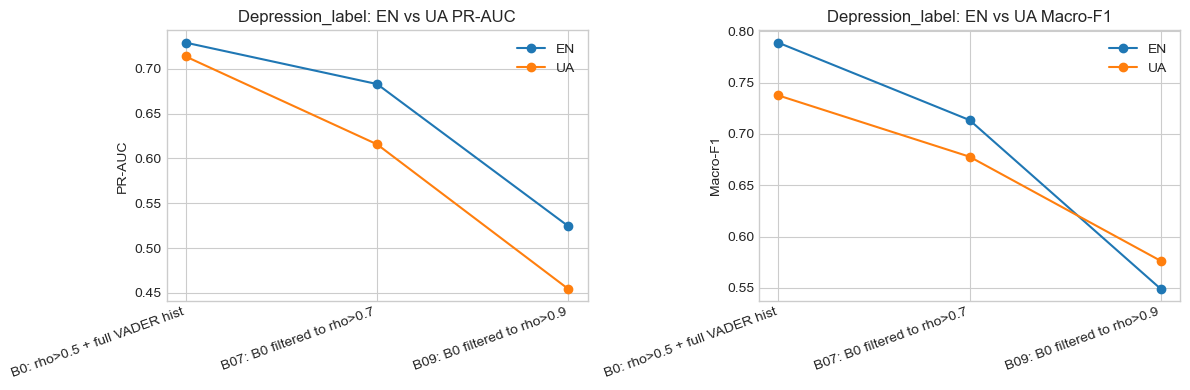

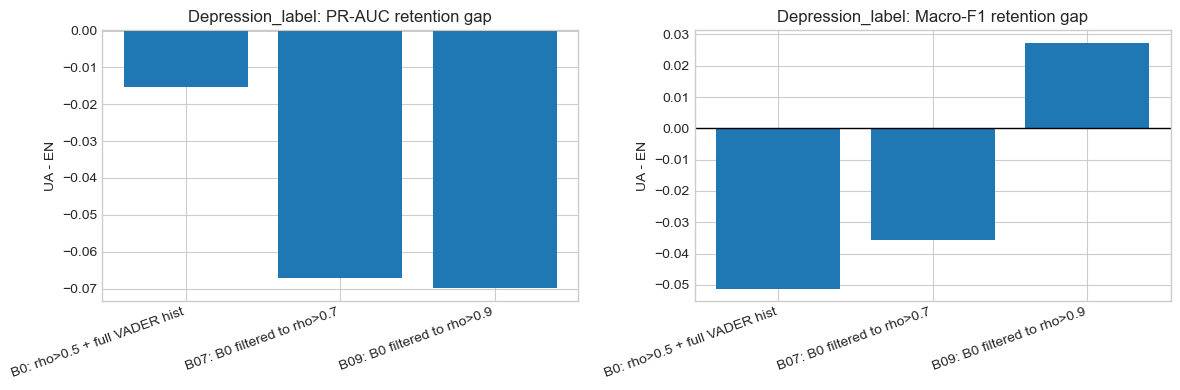

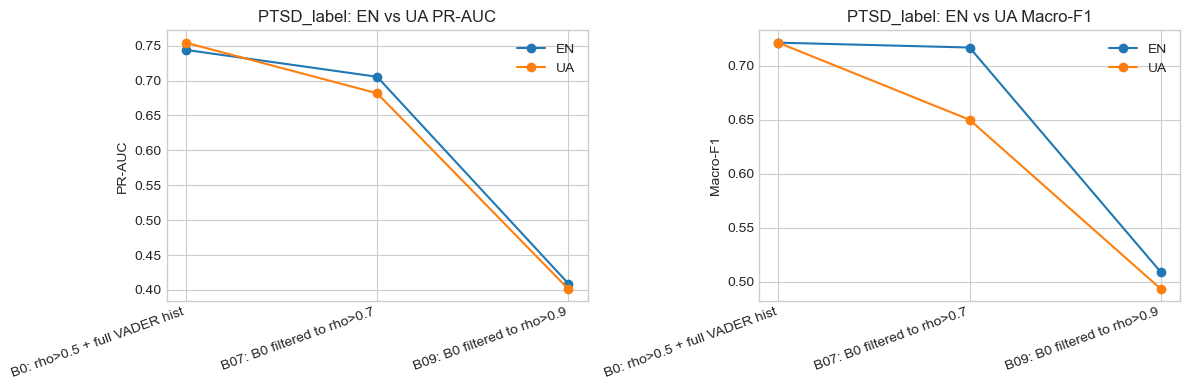

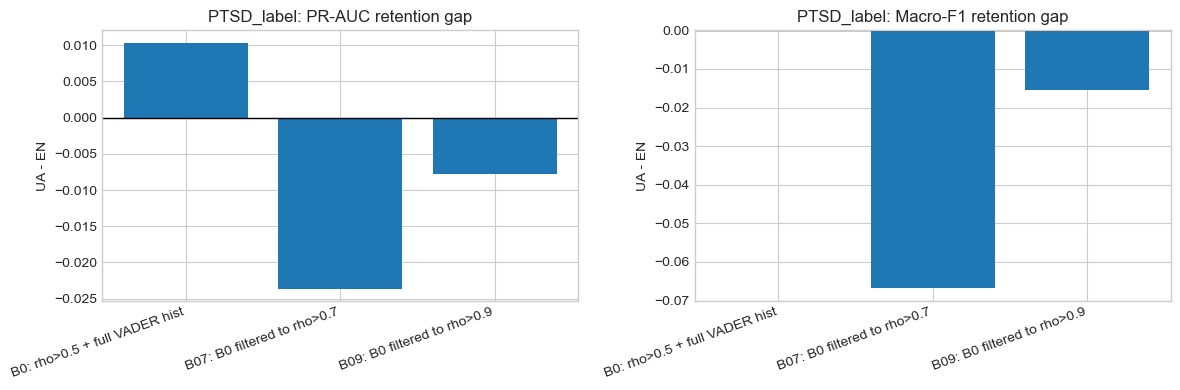

In [10]:
metric_specs = [
    ("PR-AUC", "EN_test_pr", "UA_test_pr", "delta_pr_ua_minus_en"),
    ("Macro-F1", "EN_test_f1", "UA_test_f1", "delta_f1_ua_minus_en"),
]

for target in TARGETS:
    target_df = section5_df[section5_df["target"] == target].copy()
    target_df = target_df.sort_values("family_order")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    x = np.arange(len(target_df))
    labels = [FAMILY_LABELS[name] for name in target_df["family"]]

    axes[0].plot(x, target_df["EN_test_pr"], marker="o", label="EN")
    axes[0].plot(x, target_df["UA_test_pr"], marker="o", label="UA")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20, ha="right")
    axes[0].set_ylabel("PR-AUC")
    axes[0].set_title(f"{target}: EN vs UA PR-AUC")
    axes[0].legend()

    axes[1].plot(x, target_df["EN_test_f1"], marker="o", label="EN")
    axes[1].plot(x, target_df["UA_test_f1"], marker="o", label="UA")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20, ha="right")
    axes[1].set_ylabel("Macro-F1")
    axes[1].set_title(f"{target}: EN vs UA Macro-F1")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{target}_en_vs_ua_metrics.png", dpi=180, bbox_inches="tight")
    plt.show()

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(x, target_df["delta_pr_ua_minus_en"])
    axes[0].axhline(0.0, color="black", linewidth=1)
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(labels, rotation=20, ha="right")
    axes[0].set_ylabel("UA - EN")
    axes[0].set_title(f"{target}: PR-AUC retention gap")

    axes[1].bar(x, target_df["delta_f1_ua_minus_en"])
    axes[1].axhline(0.0, color="black", linewidth=1)
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(labels, rotation=20, ha="right")
    axes[1].set_ylabel("UA - EN")
    axes[1].set_title(f"{target}: Macro-F1 retention gap")

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{target}_retention_gaps.png", dpi=180, bbox_inches="tight")
    plt.show()


## Feature importance for best EN-side and UA-side rows

For interpretability, we extract signed linear coefficients for:

- the **best EN-side family** per target, ranked by EN test macro-F1 then PR-AUC
- the **best UA-side family** per target, ranked by frozen-transfer UA test macro-F1 then PR-AUC

These are still **English-trained** models. The “best UA” row means the family that transfers best to Ukrainian under the
frozen EN-to-UA protocol, not a separately retrained Ukrainian model.


In [11]:
def choose_best_metric_row(
    df: pd.DataFrame,
    f1_col: str,
    pr_col: str,
    roc_col: str,
    tie_epsilon: float = 0.005,
) -> pd.Series:
    best_f1 = float(df[f1_col].max())
    near = df.loc[df[f1_col] >= (best_f1 - tie_epsilon)].copy()
    near = near.sort_values(
        [pr_col, f1_col, roc_col, "n_features", "family"],
        ascending=[False, False, False, True, True],
    ).reset_index(drop=True)
    return near.iloc[0]


def extract_linear_importance(target: str, family_name: str, view_name: str) -> pd.DataFrame:
    row = section3_best_df.loc[
        section3_best_df["target"].eq(target) & section3_best_df["family"].eq(family_name)
    ].iloc[0]
    payload = json.loads(row["config_json"])
    feature_columns = list(payload["feature_columns"])

    train_mask = en_df["split"].astype(str).str.lower().isin(["train", "dev"])
    X_en_train = en_df.loc[train_mask, feature_columns].reset_index(drop=True)
    y_en_train = en_df.loc[train_mask, target].astype(int).reset_index(drop=True)

    pipe = build_pipeline_from_payload(payload)
    pipe.fit(X_en_train, y_en_train)
    coef = np.asarray(pipe.named_steps["model"].coef_).ravel()

    importance_df = pd.DataFrame(
        {
            "target": target,
            "selection_view": view_name,
            "family": family_name,
            "family_label": FAMILY_LABELS[family_name],
            "model": payload["model"]["name"],
            "n_features": len(feature_columns),
            "feature": feature_columns,
            "signed_coef": coef,
            "abs_coef": np.abs(coef),
        }
    )
    importance_df = importance_df.sort_values(
        ["abs_coef", "feature"], ascending=[False, True]
    ).reset_index(drop=True)
    importance_df["coef_rank_abs"] = np.arange(1, len(importance_df) + 1)
    return importance_df


section6_selection_rows = []
section6_importance_frames = []

for target in TARGETS:
    target_df = section5_df.loc[section5_df["target"].eq(target)].copy()
    best_en_row = choose_best_metric_row(target_df, "EN_test_f1", "EN_test_pr", "EN_test_roc")
    best_ua_row = choose_best_metric_row(target_df, "UA_test_f1", "UA_test_pr", "UA_test_roc")

    for view_name, picked in [("best_en", best_en_row), ("best_ua", best_ua_row)]:
        section6_selection_rows.append(
            {
                "target": target,
                "selection_view": view_name,
                "family": picked["family"],
                "family_label": FAMILY_LABELS[picked["family"]],
                "n_features": int(picked["n_features"]),
                "model": picked["model"],
                "EN_test_pr": float(picked["EN_test_pr"]),
                "EN_test_f1": float(picked["EN_test_f1"]),
                "EN_test_f1_binary": float(picked["EN_test_f1_binary"]),
                "EN_test_roc": float(picked["EN_test_roc"]),
                "UA_test_pr": float(picked["UA_test_pr"]),
                "UA_test_f1": float(picked["UA_test_f1"]),
                "UA_test_f1_binary": float(picked["UA_test_f1_binary"]),
                "UA_test_roc": float(picked["UA_test_roc"]),
            }
        )
        section6_importance_frames.append(
            extract_linear_importance(target=target, family_name=picked["family"], view_name=view_name)
        )

section6_selection_df = pd.DataFrame(section6_selection_rows).sort_values(
    ["target", "selection_view"]
).reset_index(drop=True)
section6_importance_df = pd.concat(section6_importance_frames, ignore_index=True)

section6_selection_df.to_csv(OUT_DIR / "section6_best_model_selection.csv", index=False)
section6_importance_df.to_csv(OUT_DIR / "section6_feature_importance_all.csv", index=False)

display(section6_selection_df)

section6_top15_df = (
    section6_importance_df.sort_values(["target", "selection_view", "abs_coef"], ascending=[True, True, False])
    .groupby(["target", "selection_view"], as_index=False, sort=False)
    .head(15)
    .reset_index(drop=True)
)
section6_top15_df.to_csv(OUT_DIR / "section6_feature_importance_top15.csv", index=False)
display(
    section6_top15_df[
        [
            "target",
            "selection_view",
            "family_label",
            "feature",
            "signed_coef",
            "abs_coef",
            "coef_rank_abs",
        ]
    ]
)


,target,selection_view,family,family_label,n_features,model,EN_test_pr,EN_test_f1,EN_test_f1_binary,EN_test_roc,UA_test_pr,UA_test_f1,UA_test_f1_binary,UA_test_roc
0,Depression_label,best_en,B0_rho05_vaderfull,B0: rho>0.5 + full VADER hist,82,logreg_l2_liblinear_C0.02_bal,0.729002,0.788839,0.705882,0.787330,0.713574,0.737500,0.625000,0.772247
1,Depression_label,best_ua,B0_rho05_vaderfull,B0: rho>0.5 + full VADER hist,82,logreg_l2_liblinear_C0.02_bal,0.729002,0.788839,0.705882,0.787330,0.713574,0.737500,0.625000,0.772247
2,PTSD_label,best_en,B0_rho05_vaderfull,B0: rho>0.5 + full VADER hist,82,logreg_l2_liblinear_C0.005_cwpos3.2,0.743976,0.721393,0.666667,0.806803,0.754312,0.721393,0.666667,0.813605
3,PTSD_label,best_ua,B0_rho05_vaderfull,B0: rho>0.5 + full VADER hist,82,logreg_l2_liblinear_C0.005_cwpos3.2,0.743976,0.721393,0.666667,0.806803,0.754312,0.721393,0.666667,0.813605


,target,selection_view,family_label,feature,signed_coef,abs_coef,coef_rank_abs
0,Depression_label,best_en,B0: rho>0.5 + full VADER hist,sentiment_overall,-0.233312,0.233312,1
1,Depression_label,best_en,B0: rho>0.5 + full VADER hist,vader_hist_bin_08,0.101962,0.101962,2
2,Depression_label,best_en,B0: rho>0.5 + full VADER hist,vader_hist_bin_13,0.095251,0.095251,3
3,Depression_label,best_en,B0: rho>0.5 + full VADER hist,vader_pos_tail_mass,-0.088798,0.088798,4
4,Depression_label,best_en,B0: rho>0.5 + full VADER hist,vader_hist_bin_10,0.078377,0.078377,5
5,Depression_label,best_en,B0: rho>0.5 + full VADER hist,first_person_sentiment_positive,-0.076057,0.076057,6
6,Depression_label,best_en,B0: rho>0.5 + full VADER hist,first_person_sentiment_negative,0.075573,0.075573,7
7,Depression_label,best_en,B0: rho>0.5 + full VADER hist,sentiment_pos,-0.073714,0.073714,8
8,Depression_label,best_en,B0: rho>0.5 + full VADER hist,vader_hist_bin_20,-0.071988,0.071988,9
9,Depression_label,best_en,B0: rho>0.5 + full VADER hist,first_person_sentiment_overall,-0.070789,0.070789,10


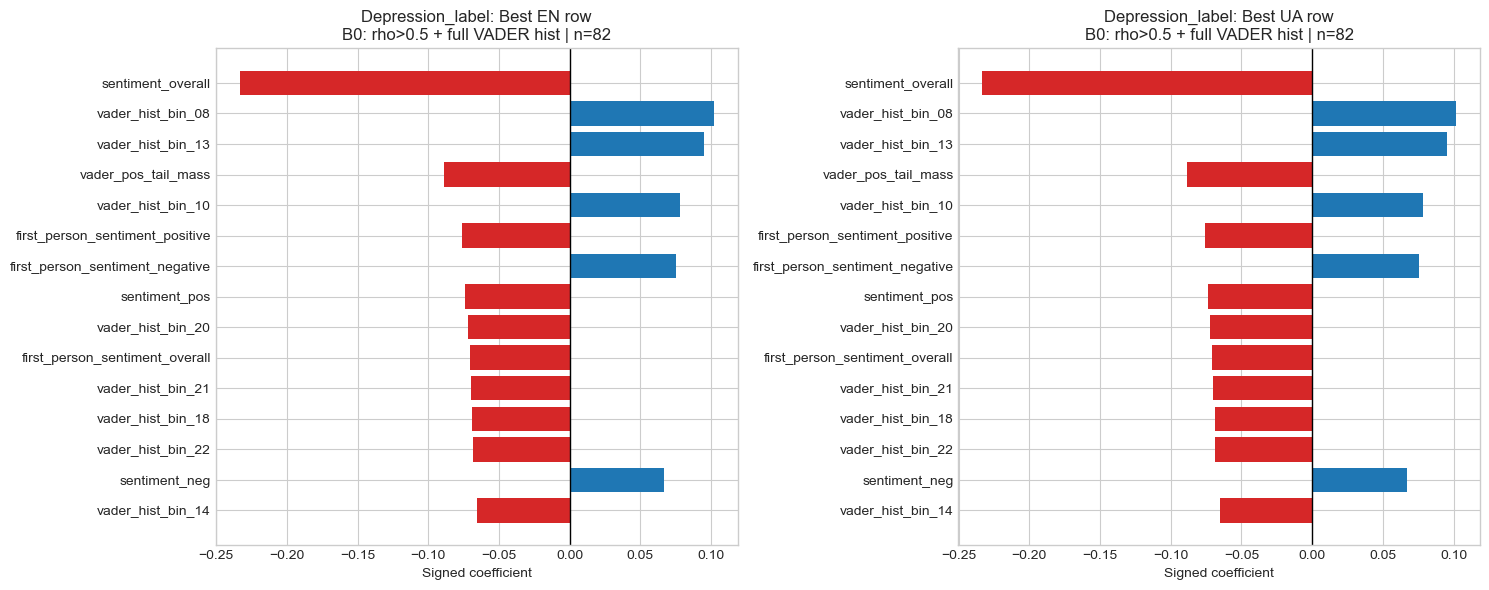

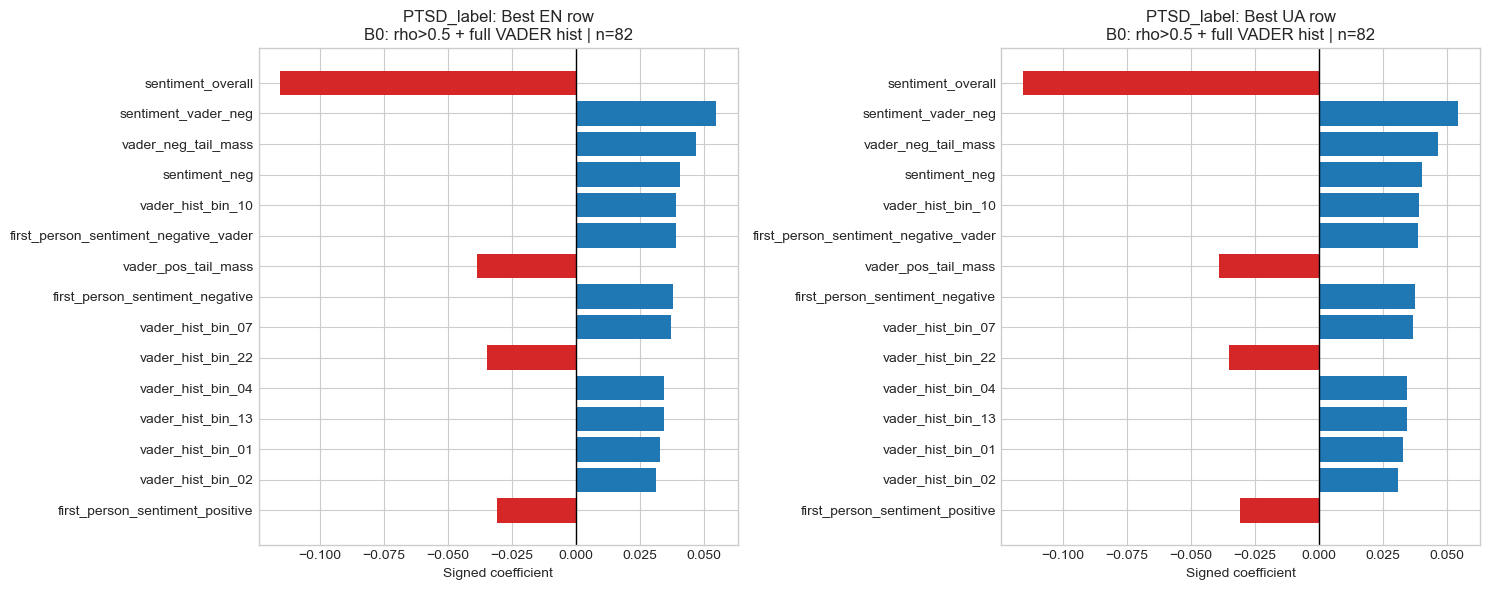

In [12]:
for target in TARGETS:
    target_sel_df = section6_selection_df.loc[section6_selection_df["target"].eq(target)].copy()
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))

    for ax, view_name in zip(axes, ["best_en", "best_ua"]):
        view_label = "Best EN row" if view_name == "best_en" else "Best UA row"
        meta_row = target_sel_df.loc[target_sel_df["selection_view"].eq(view_name)].iloc[0]
        view_df = section6_importance_df.loc[
            section6_importance_df["target"].eq(target)
            & section6_importance_df["selection_view"].eq(view_name)
        ].copy()
        view_df = view_df.sort_values("abs_coef", ascending=True).tail(15)
        colors = np.where(view_df["signed_coef"] >= 0, "#1f77b4", "#d62728")

        ax.barh(view_df["feature"], view_df["signed_coef"], color=colors)
        ax.axvline(0.0, color="black", linewidth=1)
        ax.set_title(
            f"{target}: {view_label}\n{meta_row['family_label']} | n={int(meta_row['n_features'])}"
        )
        ax.set_xlabel("Signed coefficient")

    fig.tight_layout()
    fig.savefig(FIG_DIR / f"{target}_best_en_ua_feature_importance.png", dpi=180, bbox_inches="tight")
    plt.show()


## Sentiment necessity vs sufficiency

The current winners are visibly sentiment-dominated, but coefficient magnitude alone does not tell us whether:

- sentiment is merely **important**
- sentiment is **necessary**
- sentiment is **sufficient**

We therefore run two controlled probes off the current **best EN-side row** for each target:

- **sentiment_only**: keep only the sentiment-side block
- **minus_sentiment**: drop the sentiment-side block and keep everything else

Each probe uses the same EN-only protocol as Section 3:

- same train/dev/test split
- same `simple_005_995_maxabs` preprocessing
- same `l2 liblinear` family
- same repeated OOF selection (`5x10`)
- same final threshold rule

This lets us distinguish “dominant signal source” from “standalone sufficient model”.


In [13]:
SENTIMENT_SUMMARY_COLUMNS = [
    "sentiment_neg",
    "sentiment_neu",
    "sentiment_overall",
    "sentiment_pos",
    "sentiment_vader_neg",
    "sentiment_vader_neu",
    "sentiment_vader_overall",
    "sentiment_vader_pos",
    "first_person_sentiment_negative",
    "first_person_sentiment_negative_vader",
    "first_person_sentiment_overall",
    "first_person_sentiment_overall_vader",
    "first_person_sentiment_positive",
    "first_person_sentiment_positive_vader",
]
STRICT_SENTIMENT_COLUMNS = set(SENTIMENT_SUMMARY_COLUMNS) | set(SENTIMENT_COLUMNS)


def is_sentiment_feature(name: str) -> bool:
    return (
        name.startswith("sentiment_")
        or name.startswith("first_person_sentiment_")
        or name.startswith("vader_")
        or name == "participant_utterance_count"
    )


section6_sentiment_share_rows = []
for target in TARGETS:
    target_imp = section6_importance_df.loc[
        section6_importance_df["target"].eq(target)
        & section6_importance_df["selection_view"].eq("best_en")
    ].copy()
    sentiment_mask = target_imp["feature"].map(is_sentiment_feature)
    top15 = target_imp.nsmallest(15, "coef_rank_abs").copy()
    top15_sentiment = int(top15["feature"].map(is_sentiment_feature).sum())
    total_abs = float(target_imp["abs_coef"].sum())
    sentiment_abs = float(target_imp.loc[sentiment_mask, "abs_coef"].sum())
    section6_sentiment_share_rows.append(
        {
            "target": target,
            "selection_view": "best_en",
            "total_abs_coef_sum": total_abs,
            "sentiment_abs_coef_sum": sentiment_abs,
            "sentiment_share_abs_coef": sentiment_abs / total_abs if total_abs else np.nan,
            "top15_sentiment_feature_count": top15_sentiment,
            "top15_total_feature_count": 15,
        }
    )

section6_sentiment_share_df = pd.DataFrame(section6_sentiment_share_rows).sort_values(
    ["target", "selection_view"]
).reset_index(drop=True)
section6_sentiment_share_df.to_csv(
    OUT_DIR / "section6_sentiment_importance_share_summary.csv", index=False
)
display(section6_sentiment_share_df)


,target,selection_view,total_abs_coef_sum,sentiment_abs_coef_sum,sentiment_share_abs_coef,top15_sentiment_feature_count,top15_total_feature_count
0,Depression_label,best_en,2.764525,2.060281,0.745257,15,15
1,PTSD_label,best_en,1.540459,1.118884,0.726331,15,15


In [14]:
def select_probe_best_row(search_df: pd.DataFrame, tie_epsilon: float = 0.001) -> pd.Series:
    best_combo = float(search_df["mean_combo"].max())
    near_df = search_df.loc[search_df["mean_combo"] >= (best_combo - tie_epsilon)].copy()
    near_df = near_df.sort_values(
        ["mean_oof_f1", "std_sum", "mean_oof_pr", "C"],
        ascending=[False, True, False, True],
    ).reset_index(drop=True)
    return near_df.iloc[0]


def run_sentiment_probe(
    target: str,
    mode: str,
    n_splits: int = 5,
    n_repeats: int = 10,
    tie_epsilon: float = 0.001,
) -> dict[str, object]:
    best_en_meta = section6_selection_df.loc[
        section6_selection_df["target"].eq(target)
        & section6_selection_df["selection_view"].eq("best_en")
    ].iloc[0]
    family_name = best_en_meta["family"]
    base_row = section3_best_df.loc[
        section3_best_df["target"].eq(target) & section3_best_df["family"].eq(family_name)
    ].iloc[0]
    base_payload = json.loads(base_row["config_json"])
    base_features = list(base_payload["feature_columns"])
    sentiment_features = [f for f in base_features if f in STRICT_SENTIMENT_COLUMNS]

    if mode == "sentiment_only":
        probe_features = sentiment_features
    elif mode == "minus_sentiment":
        probe_features = [f for f in base_features if f not in STRICT_SENTIMENT_COLUMNS]
    else:
        raise ValueError(f"Unknown sentiment probe mode: {mode}")

    X_train, y_train, X_test, y_test = train_test_split_for_target(
        en_df, target, probe_features
    )
    ua_test_mask = ua_df["split"].astype(str).str.lower().eq("test")
    X_ua_test = ua_df.loc[ua_test_mask, probe_features].reset_index(drop=True)
    y_ua_test = ua_df.loc[ua_test_mask, target].astype(int).reset_index(drop=True)

    search_rows = []
    for c in c_grid(target):
        for cw_suffix, cw in class_weight_grid(target):
            payload = make_payload(
                target=target,
                family_name=f"{family_name}__{mode}",
                feature_columns=probe_features,
                c=c,
                cw_suffix=cw_suffix,
                cw=cw,
            )
            summary = repeated_cv_summary(
                payload,
                X_train,
                y_train,
                n_splits=n_splits,
                n_repeats=n_repeats,
            )
            row = {
                "target": target,
                "probe_mode": mode,
                "baseline_family": family_name,
                "baseline_n_features": len(base_features),
                "n_features": len(probe_features),
                "C": c,
                "class_weight_name": cw_suffix,
                "config_json": json.dumps(payload, sort_keys=True),
                "mean_oof_pr": float(summary["mean_oof_pr"]),
                "std_oof_pr": float(summary["std_oof_pr"]),
                "mean_oof_f1": float(summary["mean_oof_f1"]),
                "std_oof_f1": float(summary["std_oof_f1"]),
                "mean_oof_f1_binary": float(summary["mean_oof_f1_binary"]),
                "mean_oof_roc": float(summary["mean_oof_roc"]),
                "threshold": float(summary["threshold_final"]),
            }
            row["mean_combo"] = 0.5 * (row["mean_oof_pr"] + row["mean_oof_f1"])
            row["min_mean_metric"] = min(row["mean_oof_pr"], row["mean_oof_f1"])
            row["std_sum"] = row["std_oof_pr"] + row["std_oof_f1"]
            search_rows.append(row)

    search_df = pd.DataFrame(search_rows).sort_values(
        ["mean_combo", "min_mean_metric", "std_sum", "C"],
        ascending=[False, False, True, True],
    ).reset_index(drop=True)
    best = select_probe_best_row(search_df, tie_epsilon=tie_epsilon)
    best_payload = json.loads(best["config_json"])

    en_metrics, _ = fit_and_eval_official(
        best_payload,
        X_train,
        y_train,
        X_test,
        y_test,
        float(best["threshold"]),
    )
    ua_metrics, _ = fit_and_eval_official(
        best_payload,
        X_train,
        y_train,
        X_ua_test,
        y_ua_test,
        float(best["threshold"]),
    )

    return {
        "target": target,
        "probe_mode": mode,
        "baseline_family": family_name,
        "baseline_feature_count": len(base_features),
        "strict_sentiment_feature_count": len(sentiment_features),
        "remaining_feature_count": len(probe_features),
        "removed_feature_count": len(base_features) - len(probe_features),
        "best_model": best_payload["model"]["name"],
        "best_C": float(best["C"]),
        "best_class_weight_name": best["class_weight_name"],
        "threshold": float(best["threshold"]),
        "mean_oof_pr": float(best["mean_oof_pr"]),
        "mean_oof_f1": float(best["mean_oof_f1"]),
        "EN_test_pr": float(en_metrics["pr_auc"]),
        "EN_test_f1": float(en_metrics["f1_macro"]),
        "EN_test_f1_binary": float(en_metrics["f1_binary"]),
        "EN_test_roc": float(en_metrics["roc_auc"]),
        "UA_test_pr": float(ua_metrics["pr_auc"]),
        "UA_test_f1": float(ua_metrics["f1_macro"]),
        "UA_test_f1_binary": float(ua_metrics["f1_binary"]),
        "UA_test_roc": float(ua_metrics["roc_auc"]),
    }


section6_probe_rows = []
for target in TARGETS:
    for probe_mode in ["sentiment_only", "minus_sentiment"]:
        section6_probe_rows.append(run_sentiment_probe(target=target, mode=probe_mode))

section6_probe_df = pd.DataFrame(section6_probe_rows).sort_values(
    ["target", "probe_mode"]
).reset_index(drop=True)


In [15]:
section6_baseline_probe_rows = []
for target in TARGETS:
    best_en_meta = section6_selection_df.loc[
        section6_selection_df["target"].eq(target)
        & section6_selection_df["selection_view"].eq("best_en")
    ].iloc[0]
    section6_baseline_probe_rows.append(
        {
            "target": target,
            "probe_mode": "full_baseline",
            "baseline_family": best_en_meta["family"],
            "baseline_feature_count": int(best_en_meta["n_features"]),
            "strict_sentiment_feature_count": int(
                (
                    section6_importance_df.loc[
                        section6_importance_df["target"].eq(target)
                        & section6_importance_df["selection_view"].eq("best_en"),
                        "feature",
                    ]
                    .map(lambda x: x in STRICT_SENTIMENT_COLUMNS)
                    .sum()
                )
            ),
            "remaining_feature_count": int(best_en_meta["n_features"]),
            "removed_feature_count": 0,
            "best_model": best_en_meta["model"],
            "best_C": np.nan,
            "best_class_weight_name": np.nan,
            "threshold": np.nan,
            "mean_oof_pr": np.nan,
            "mean_oof_f1": np.nan,
            "EN_test_pr": float(best_en_meta["EN_test_pr"]),
            "EN_test_f1": float(best_en_meta["EN_test_f1"]),
            "EN_test_f1_binary": float(best_en_meta["EN_test_f1_binary"]),
            "EN_test_roc": float(best_en_meta["EN_test_roc"]),
            "UA_test_pr": float(best_en_meta["UA_test_pr"]),
            "UA_test_f1": float(best_en_meta["UA_test_f1"]),
            "UA_test_f1_binary": float(best_en_meta["UA_test_f1_binary"]),
            "UA_test_roc": float(best_en_meta["UA_test_roc"]),
        }
    )

section6_sentiment_probe_df = pd.concat(
    [pd.DataFrame(section6_baseline_probe_rows), section6_probe_df],
    ignore_index=True,
)

baseline_lookup = (
    section6_sentiment_probe_df.loc[section6_sentiment_probe_df["probe_mode"].eq("full_baseline")]
    .set_index("target")
    .to_dict("index")
)

for metric in ["EN_test_pr", "EN_test_f1", "UA_test_pr", "UA_test_f1"]:
    delta_col = metric.replace("_test_", "_delta_")
    section6_sentiment_probe_df[delta_col] = section6_sentiment_probe_df.apply(
        lambda row: float(row[metric]) - float(baseline_lookup[row["target"]][metric]),
        axis=1,
    )

section6_sentiment_probe_df.to_csv(
    OUT_DIR / "section6_sentiment_necessity_sufficiency.csv", index=False
)

display(
    section6_sentiment_probe_df[
        [
            "target",
            "probe_mode",
            "remaining_feature_count",
            "EN_test_pr",
            "EN_test_f1",
            "UA_test_pr",
            "UA_test_f1",
            "EN_delta_pr",
            "EN_delta_f1",
            "UA_delta_pr",
            "UA_delta_f1",
        ]
    ].sort_values(["target", "probe_mode"])
)


,target,probe_mode,remaining_feature_count,EN_test_pr,EN_test_f1,UA_test_pr,UA_test_f1,EN_delta_pr,EN_delta_f1,UA_delta_pr,UA_delta_f1
0,Depression_label,full_baseline,82,0.729002,0.788839,0.713574,0.737500,0.000000,0.000000,0.000000,0.000000
2,Depression_label,minus_sentiment,40,0.376527,0.475000,0.406738,0.499187,-0.352475,-0.313839,-0.306836,-0.238313
3,Depression_label,sentiment_only,42,0.721666,0.695238,0.725524,0.672965,-0.007336,-0.093601,0.011950,-0.064535
1,PTSD_label,full_baseline,82,0.743976,0.721393,0.754312,0.721393,0.000000,0.000000,0.000000,0.000000
4,PTSD_label,minus_sentiment,40,0.388531,0.526042,0.401943,0.504762,-0.355445,-0.195351,-0.352370,-0.216631
5,PTSD_label,sentiment_only,42,0.751099,0.711439,0.774760,0.672965,0.007123,-0.009954,0.020447,-0.048428


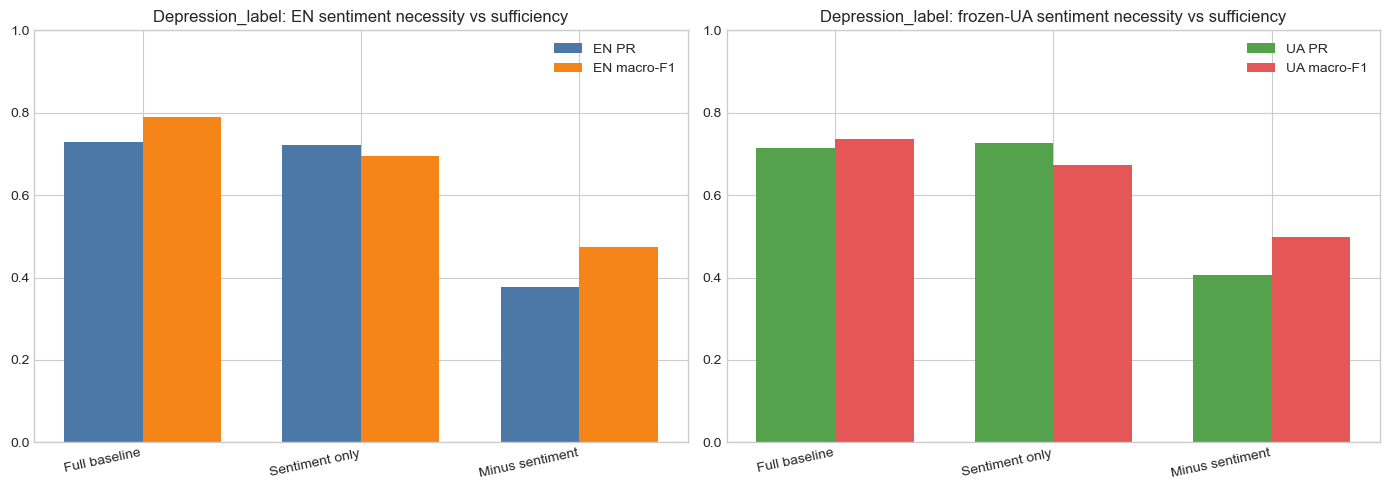

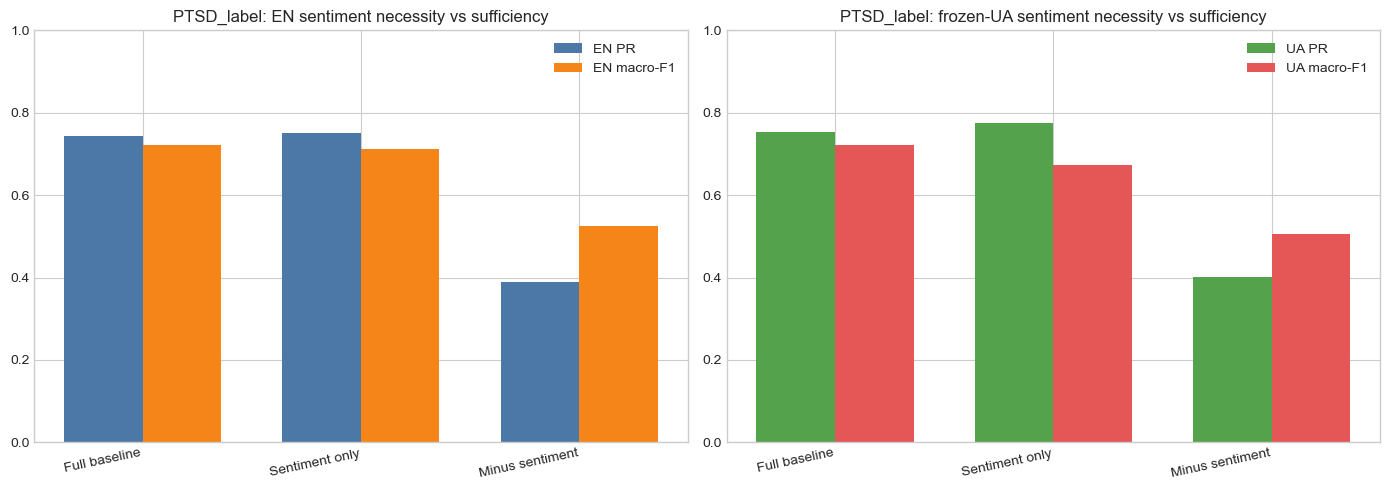

In [16]:
for target in TARGETS:
    target_df = section6_sentiment_probe_df.loc[
        section6_sentiment_probe_df["target"].eq(target)
    ].copy()
    target_df["probe_label"] = target_df["probe_mode"].map(
        {
            "full_baseline": "Full baseline",
            "sentiment_only": "Sentiment only",
            "minus_sentiment": "Minus sentiment",
        }
    )
    target_df["probe_order"] = target_df["probe_mode"].map(
        {"full_baseline": 0, "sentiment_only": 1, "minus_sentiment": 2}
    )
    target_df = target_df.sort_values("probe_order").reset_index(drop=True)
    x = np.arange(len(target_df))
    width = 0.36

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    axes[0].bar(x - width / 2, target_df["EN_test_pr"], width=width, label="EN PR", color="#4C78A8")
    axes[0].bar(x + width / 2, target_df["EN_test_f1"], width=width, label="EN macro-F1", color="#F58518")
    axes[0].set_xticks(x)
    axes[0].set_xticklabels(target_df["probe_label"], rotation=12, ha="right")
    axes[0].set_ylim(0, 1)
    axes[0].set_title(f"{target}: EN sentiment necessity vs sufficiency")
    axes[0].legend()

    axes[1].bar(x - width / 2, target_df["UA_test_pr"], width=width, label="UA PR", color="#54A24B")
    axes[1].bar(x + width / 2, target_df["UA_test_f1"], width=width, label="UA macro-F1", color="#E45756")
    axes[1].set_xticks(x)
    axes[1].set_xticklabels(target_df["probe_label"], rotation=12, ha="right")
    axes[1].set_ylim(0, 1)
    axes[1].set_title(f"{target}: frozen-UA sentiment necessity vs sufficiency")
    axes[1].legend()

    fig.tight_layout()
    fig.savefig(
        FIG_DIR / f"{target}_sentiment_necessity_sufficiency.png",
        dpi=180,
        bbox_inches="tight",
    )
    plt.show()


## Concise interpretation summary

This section compresses the main Section 6 findings into one target-level summary:

- which family wins on the current EN-first protocol
- how much of the coefficient mass is sentiment-side
- whether sentiment-only is enough
- whether removing sentiment breaks the model

The goal is to leave the paper-facing takeaway explicit without reopening broader exploratory comparisons.


In [17]:
section6_interp_rows = []

for target in TARGETS:
    best_en_row = section6_selection_df.loc[
        section6_selection_df["target"].eq(target)
        & section6_selection_df["selection_view"].eq("best_en")
    ].iloc[0]
    sent_share_row = section6_sentiment_share_df.loc[
        section6_sentiment_share_df["target"].eq(target)
        & section6_sentiment_share_df["selection_view"].eq("best_en")
    ].iloc[0]
    sent_only_row = section6_sentiment_probe_df.loc[
        section6_sentiment_probe_df["target"].eq(target)
        & section6_sentiment_probe_df["probe_mode"].eq("sentiment_only")
    ].iloc[0]
    minus_sent_row = section6_sentiment_probe_df.loc[
        section6_sentiment_probe_df["target"].eq(target)
        & section6_sentiment_probe_df["probe_mode"].eq("minus_sentiment")
    ].iloc[0]

    section6_interp_rows.append(
        {
            "target": target,
            "best_en_family": best_en_row["family"],
            "best_en_family_label": best_en_row["family_label"],
            "best_en_model": best_en_row["model"],
            "best_en_n_features": int(best_en_row["n_features"]),
            "EN_test_pr": float(best_en_row["EN_test_pr"]),
            "EN_test_f1": float(best_en_row["EN_test_f1"]),
            "UA_test_pr": float(best_en_row["UA_test_pr"]),
            "UA_test_f1": float(best_en_row["UA_test_f1"]),
            "sentiment_share_abs_coef": float(sent_share_row["sentiment_share_abs_coef"]),
            "top15_sentiment_feature_count": int(sent_share_row["top15_sentiment_feature_count"]),
            "sentiment_only_n_features": int(sent_only_row["remaining_feature_count"]),
            "sentiment_only_EN_delta_f1": float(sent_only_row["EN_delta_f1"]),
            "sentiment_only_UA_delta_f1": float(sent_only_row["UA_delta_f1"]),
            "minus_sentiment_n_features": int(minus_sent_row["remaining_feature_count"]),
            "minus_sentiment_EN_delta_f1": float(minus_sent_row["EN_delta_f1"]),
            "minus_sentiment_UA_delta_f1": float(minus_sent_row["UA_delta_f1"]),
            "concise_takeaway": (
                "Sentiment dominates the model but is not sufficient on its own; "
                "sentiment-only loses macro-F1, while removing sentiment collapses performance."
            ),
        }
    )

section6_interpretation_df = pd.DataFrame(section6_interp_rows).sort_values("target").reset_index(drop=True)
section6_interpretation_df.to_csv(OUT_DIR / "section6_interpretation_summary.csv", index=False)

display(
    section6_interpretation_df[
        [
            "target",
            "best_en_family_label",
            "best_en_model",
            "best_en_n_features",
            "EN_test_pr",
            "EN_test_f1",
            "UA_test_pr",
            "UA_test_f1",
            "sentiment_share_abs_coef",
            "sentiment_only_EN_delta_f1",
            "minus_sentiment_EN_delta_f1",
            "sentiment_only_UA_delta_f1",
            "minus_sentiment_UA_delta_f1",
            "concise_takeaway",
        ]
    ]
)


,target,best_en_family_label,best_en_model,best_en_n_features,EN_test_pr,EN_test_f1,UA_test_pr,UA_test_f1,sentiment_share_abs_coef,sentiment_only_EN_delta_f1,minus_sentiment_EN_delta_f1,sentiment_only_UA_delta_f1,minus_sentiment_UA_delta_f1,concise_takeaway
0,Depression_label,B0: rho>0.5 + full VADER hist,logreg_l2_liblinear_C0.02_bal,82,0.729002,0.788839,0.713574,0.737500,0.745257,-0.093601,-0.313839,-0.064535,-0.238313,Sentiment dominates the model but is not suffi...
1,PTSD_label,B0: rho>0.5 + full VADER hist,logreg_l2_liblinear_C0.005_cwpos3.2,82,0.743976,0.721393,0.754312,0.721393,0.726331,-0.009954,-0.195351,-0.048428,-0.216631,Sentiment dominates the model but is not suffi...


## Outputs written by this notebook

The notebook writes:

- `section0_baseline_family_winners.csv`
- `section0_baseline_overall_winners.csv`
- `family_feature_counts.csv`
- `family_feature_membership.csv`
- `section3_en_search_all.csv`
- `section3_en_selected_models.csv`
- `section3_en_test_predictions.csv`
- `section4_bootstrap_ci_summary.csv`
- `section4_frozen_transfer_results.csv`
- `section4_en_ua_test_predictions.csv`
- `section5_signal_retention_summary.csv`
- `section6_best_model_selection.csv`
- `section6_feature_importance_all.csv`
- `section6_feature_importance_top15.csv`
- `section6_sentiment_importance_share_summary.csv`
- `section6_sentiment_necessity_sufficiency.csv`
- `section6_interpretation_summary.csv`
- figures in `figures/`

This keeps the notebook paper-friendly while still exporting the full tables used in the analysis.
